<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/C1_Log%E2%80%93%CE%A8_%E2%80%94_Extended_Run_with_Continuous_Perturbation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Extended Log–Ψ Statistics ===
Total recurrence steps: 6000
Mean Ψ:     -0.00009
Std Ψ:      0.08109
Min Ψ:      -0.51590
Max Ψ:      0.28993

Regime distribution (C1 classification):
  Growth (Ψ > 0.01):      2669 steps (44.5%)
  Decay (Ψ < -0.01):      2663 steps (44.4%)
  Quasi-stationary:        667 steps (11.1%)

Mean S (last 1000 steps): 0.0876


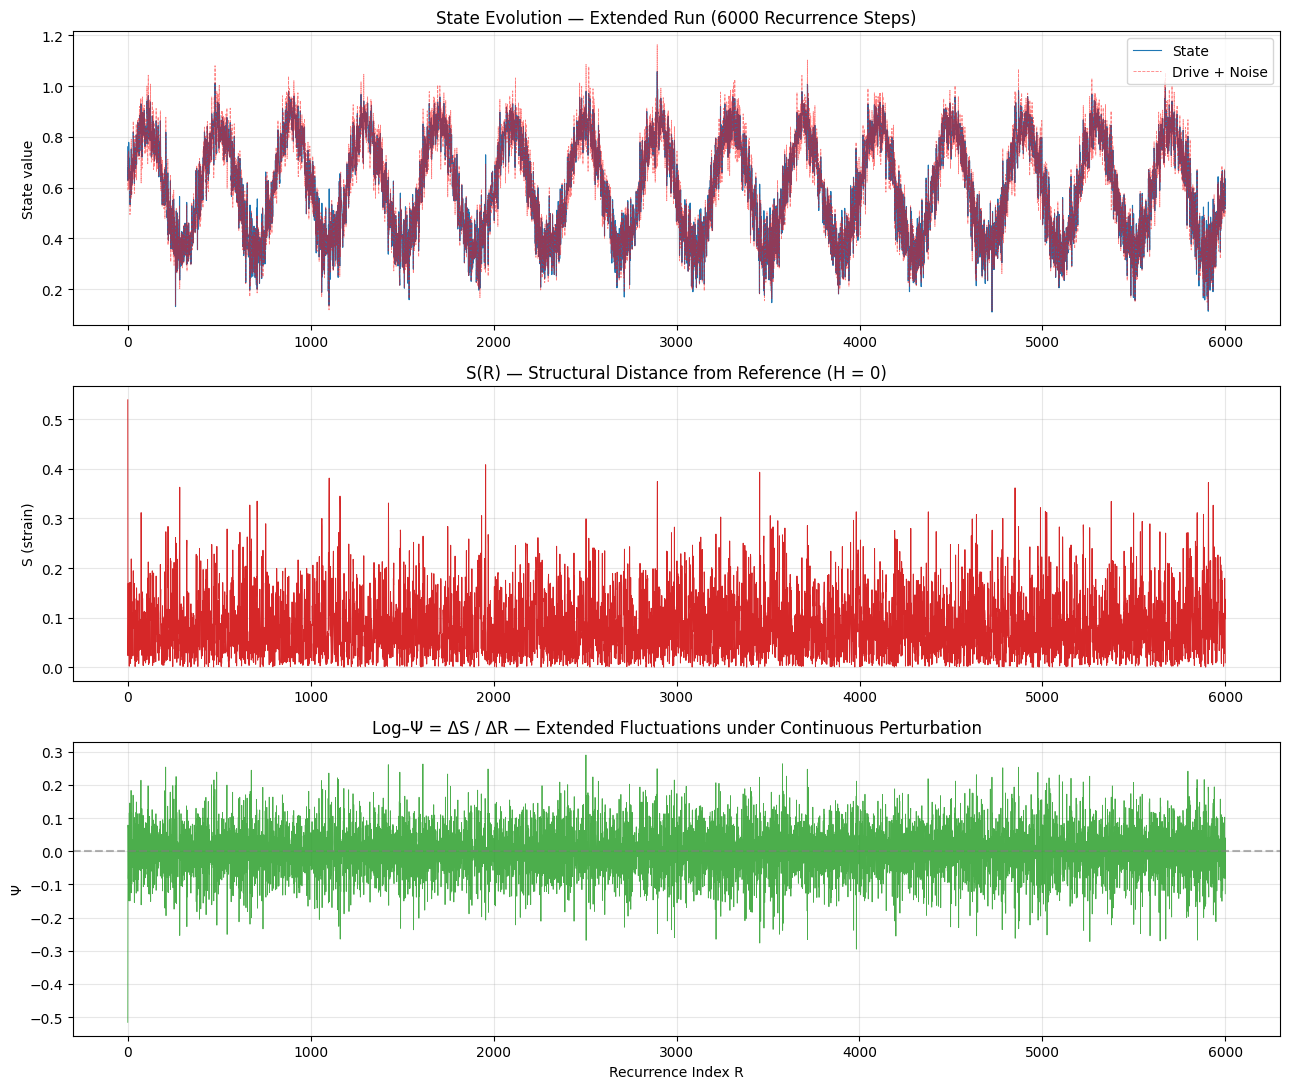

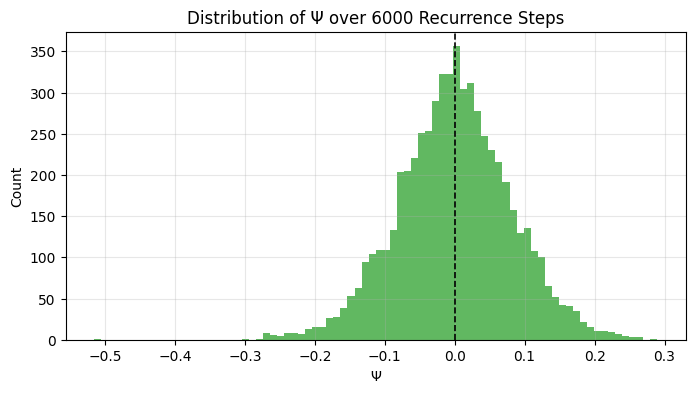

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# C1 Log–Ψ — Extended Run with Continuous Perturbation
# ============================================================

np.random.seed(42)

n_steps = 6000
R = np.arange(n_steps)

state = np.random.randn(1) * 0.1

# PID gains
Kp = 0.8
Ki = 0.15
Kd = 0.25
constraint = 0.55

# Noise level
noise_amplitude = 0.08

# Storage
S = np.zeros(n_steps)
psi = np.zeros(n_steps - 1)
drive_history = np.zeros(n_steps)
state_history = np.zeros(n_steps)

integral = 0.0
prev_error = 0.0

for i in range(n_steps):
    base_drive = 0.6 + 0.25 * np.sin(2 * np.pi * i / 400)
    drive = base_drive + noise_amplitude * np.random.randn()

    error = drive - state[0]
    strain = abs(error)

    integral += error * 1.0
    derivative = (error - prev_error)
    pid_output = Kp * error + Ki * integral + Kd * derivative
    reorganization = pid_output * (1 - constraint * abs(state[0]))

    state = state + reorganization
    prev_error = error

    S[i] = strain
    drive_history[i] = drive
    state_history[i] = state[0]

# Compute Log–Ψ
dS = np.diff(S)
dR = np.diff(R)
psi = dS / dR

# ============================================================
# Statistical Analysis of Ψ
# ============================================================
psi_mean = np.mean(psi)
psi_std = np.std(psi)
psi_min = np.min(psi)
psi_max = np.max(psi)

# Regime counting (per C1 thresholds)
growth_steps = np.sum(psi > 0.01)
decay_steps = np.sum(psi < -0.01)
stationary_steps = np.sum((psi >= -0.01) & (psi <= 0.01))

total_psi_steps = len(psi)

print("=== Extended Log–Ψ Statistics ===")
print(f"Total recurrence steps: {n_steps}")
print(f"Mean Ψ:     {psi_mean:.5f}")
print(f"Std Ψ:      {psi_std:.5f}")
print(f"Min Ψ:      {psi_min:.5f}")
print(f"Max Ψ:      {psi_max:.5f}")
print()
print("Regime distribution (C1 classification):")
print(f"  Growth (Ψ > 0.01):     {growth_steps:5d} steps ({100*growth_steps/total_psi_steps:.1f}%)")
print(f"  Decay (Ψ < -0.01):     {decay_steps:5d} steps ({100*decay_steps/total_psi_steps:.1f}%)")
print(f"  Quasi-stationary:      {stationary_steps:5d} steps ({100*stationary_steps/total_psi_steps:.1f}%)")
print()
print(f"Mean S (last 1000 steps): {np.mean(S[-1000:]):.4f}")

# ============================================================
# Plotting
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# State + Drive
axes[0].plot(R, state_history, color='#1f77b4', linewidth=0.8, label='State')
axes[0].plot(R, drive_history, color='red', linestyle='--', linewidth=0.6, alpha=0.5, label='Drive + Noise')
axes[0].set_title("State Evolution — Extended Run (6000 Recurrence Steps)")
axes[0].set_ylabel("State value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# S(R)
axes[1].plot(R, S, color='#d62728', linewidth=0.7)
axes[1].set_title("S(R) — Structural Distance from Reference (H = 0)")
axes[1].set_ylabel("S (strain)")
axes[1].grid(True, alpha=0.3)

# Ψ(R) + Histogram inset
axes[2].plot(R[1:], psi, color='#2ca02c', linewidth=0.6, alpha=0.85)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title("Log–Ψ = ΔS / ΔR — Extended Fluctuations under Continuous Perturbation")
axes[2].set_xlabel("Recurrence Index R")
axes[2].set_ylabel("Ψ")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Histogram of Ψ
plt.figure(figsize=(8, 4))
plt.hist(psi, bins=80, color='#2ca02c', alpha=0.75, edgecolor='none')
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title("Distribution of Ψ over 6000 Recurrence Steps")
plt.xlabel("Ψ")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()